# Estatísticas das Saídas

In [5]:
import pandas as pd
caminho = '../'

y_test = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv')
predicoes = pd.read_csv('predictions.csv', header=None)
probas = pd.read_csv('probabilities.csv', header=None)

 Modelo       | Acura  | Preci  | Recal  | F1-sco |  MCC   |  AUC  
knn_def_exp1  |  77.48 |  74.32 |  74.67 | 0.7449 | 0.4899 | 0.7998
knn_otz_exp1  |  81.98 |  80.31 |  77.28 | 0.7844 | 0.5751 | 0.8411
knn_def_exp2  |  78.38 |  75.33 |  75.33 | 0.7533 | 0.5067 | 0.7850
knn_otz_exp2  |  79.28 |  76.73 |  74.56 | 0.7542 | 0.5124 | 0.8448
rf_def_exp1   |  79.28 |  77.51 |  73.11 | 0.7451 | 0.5043 | 0.8469
rf_otz_exp1   |  81.08 |  79.96 |  75.17 | 0.7673 | 0.5492 | 0.8730
rf_def_exp2   |  73.87 |  71.11 |  64.78 | 0.6577 | 0.3533 | 0.8157
rf_otz_exp2   |  76.58 |  75.13 |  68.22 | 0.6966 | 0.4280 | 0.8207
svm_def_exp1  |  81.08 |  79.96 |  75.17 | 0.7673 | 0.5492 | 0.8611
svm_otz_exp1  |  82.88 |  81.21 |  78.67 | 0.7969 | 0.5982 | 0.8389
svm_def_exp2  |  80.18 |  78.46 |  74.50 | 0.7585 | 0.5282 | 0.8681
svm_otz_exp2  |  81.08 |  79.39 |  75.89 | 0.7716 | 0.5517 | 0.8211
xgb_def_exp1  |  78.38 |  75.38 |  74.61 | 0.7496 | 0.4999 | 0.8459
xgb_otz_exp1  |  78.38 |  75.33 |  75.33 | 0.753

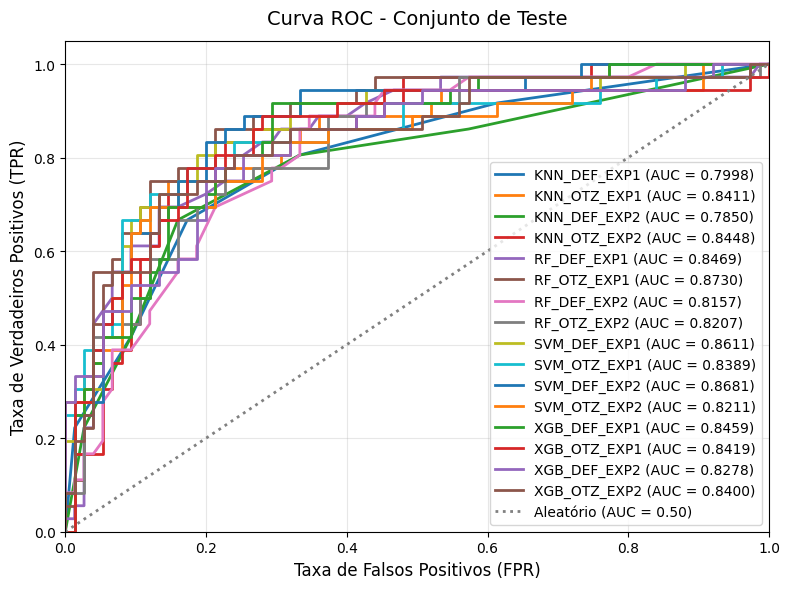

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# Configura a figura única para a Curva ROC de Teste
plt.figure(figsize=(8, 6))

print('=' * 65)
print(' Modelo       | Acura  | Preci  | Recal  | F1-sco |  MCC   |  AUC  ')
print('=' * 65)

# Garante que y_test esteja no formato 1D de inteiros
y_true = y_test.values.ravel().astype(int)

# 3. Itera sobre cada modelo salvo nas predições
for i in range(len(predicoes)):
    # Recupera nome do modelo e os arrays de predição/probabilidade
    nome_modelo = predicoes.iloc[i, 0]
    y_pred = predicoes.iloc[i, 2:].dropna().astype(int).values
    y_proba = probas.iloc[i, 2:].dropna().astype(float).values

    # Cálculo das Métricas
    acuracia = accuracy_score(y_true, y_pred) * 100
    precisao = (
        precision_score(y_true, y_pred, average='macro', zero_division=0) * 100
    )
    recall = (
        recall_score(y_true, y_pred, average='macro', zero_division=0) * 100
    )
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)

    # Imprime a linha formatada na tabela
    print(
        f'{nome_modelo:<13} | {acuracia:6.2f} | {precisao:6.2f} | {recall:6.2f} | {f1:6.4f} | {mcc:6.4f} | {auc:6.4f}'
    )

    # Curva ROC do modelo atual
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    plt.plot(fpr, tpr, lw=2, label=f'{nome_modelo.upper()} (AUC = {auc:.4f})')

print('=' * 65)

# 4. Linha de baseline aleatória e estilização do gráfico
plt.plot(
    [0, 1],
    [0, 1],
    color='gray',
    lw=2,
    linestyle=':',
    label='Aleatório (AUC = 0.50)',
)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.title('Curva ROC - Conjunto de Teste', fontsize=14, pad=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()